In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import langid

In [2]:
df= pd.read_csv("data/blogtext.csv")
print(f"The shape of the dataframe:{df.shape}")

The shape of the dataframe:(681284, 7)


<h1>intial checking and cleaning (dropping columns and nan values)

In [3]:
df.head()

,id,gender,age,topic,sign,date,text
0,2059027,male,15,Student,Leo,"14,May,2004","Info has been found (+/- 100 pages,..."
1,2059027,male,15,Student,Leo,"13,May,2004",These are the team members: Drewe...
2,2059027,male,15,Student,Leo,"12,May,2004",In het kader van kernfusie op aarde...
3,2059027,male,15,Student,Leo,"12,May,2004",testing!!! testing!!!
4,3581210,male,33,InvestmentBanking,Aquarius,"11,June,2004",Thanks to Yahoo!'s Toolbar I can ...


<h3> dropping sign column

* I will take only 0.1 for faster EDA and preproccing


In [4]:
ndf = df.drop(columns="sign").sample(frac=0.05,random_state=32,ignore_index=True)

In [5]:
ndf.shape

(34064, 6)

<h3>cheacking for dups, nan

In [6]:
ndf.duplicated().sum()

np.int64(48)

In [7]:
ndf.drop_duplicates(inplace=True)

In [8]:
ndf.duplicated().sum()

np.int64(0)

In [9]:
ndf.isna().sum()

id        0
gender    0
age       0
topic     0
date      0
text      0
dtype: int64

<h2> Cleaning data using regex and external libraries

<h2> Text Column

<h3> checking for non-english

* created column lang for language

In [10]:
ndf["Lang"]=ndf["text"].apply(lambda x: langid.classify(x)[0])

In [11]:
ndf["Lang"].value_counts()

Lang
en    33304
de       85
es       75
fr       58
tl       50
      ...  
eo        1
qu        1
hu        1
he        1
lo        1
Name: count, Length: 64, dtype: int64

In [12]:
def grouping(x):
    if x == "en":
        x= "en"
    else:
        x= "non-en"
    return x

In [13]:
ndf["Lang"]=ndf["Lang"].apply(lambda x:grouping(x))

In [14]:
ndf["Lang"].value_counts()

Lang
en        33304
non-en      712
Name: count, dtype: int64

<h1> Date column

<h2> conferting date cloumn into Date

In [15]:
ndf["date_cleaned"] = pd.to_datetime(ndf["date"],errors="coerce")

In [16]:
#checking everything worked
ndf["date_cleaned"]

0       2004-07-02
1       2004-08-05
2       2004-03-30
3       2004-03-29
4       2004-04-20
           ...    
34059   2004-07-19
34060   2003-10-14
34061          NaT
34062   2003-08-14
34063   2004-08-18
Name: date_cleaned, Length: 34016, dtype: datetime64[ns]

In [17]:
ndf["date"] = ndf["date_cleaned"]

<h2> making date into year month day

In [18]:
ndf["year"] = ndf["date"].apply(lambda x:x.year)
ndf["month"] = ndf["date"].apply(lambda x:x.month)
ndf["day"] = ndf["date"].apply(lambda x:x.day)

In [19]:
ndf.head()

,id,gender,age,topic,date,text,Lang,date_cleaned,year,month,day
0,1999563,female,14,Student,2004-07-02,hahahha. I have do this impr...,en,2004-07-02,2004.0,7.0,2.0
1,3898151,female,16,indUnk,2004-08-05,Today First of All is ok in school hav...,en,2004-08-05,2004.0,8.0,5.0
2,1270648,female,23,indUnk,2004-03-30,Not bloody likely...,en,2004-03-30,2004.0,3.0,30.0
3,3034743,female,17,Student,2004-03-29,The things I do for Josh...haha j/k. He...,en,2004-03-29,2004.0,3.0,29.0
4,2402439,male,25,indUnk,2004-04-20,Buy this now!!!!,en,2004-04-20,2004.0,4.0,20.0


In [20]:
#dropping date column
ndf = ndf.drop(columns=["date","date_cleaned"])

In [21]:
ndf

,id,gender,age,topic,text,Lang,year,month,day
0,1999563,female,14,Student,hahahha. I have do this impr...,en,2004.0,7.0,2.0
1,3898151,female,16,indUnk,Today First of All is ok in school hav...,en,2004.0,8.0,5.0
2,1270648,female,23,indUnk,Not bloody likely...,en,2004.0,3.0,30.0
3,3034743,female,17,Student,The things I do for Josh...haha j/k. He...,en,2004.0,3.0,29.0
4,2402439,male,25,indUnk,Buy this now!!!!,en,2004.0,4.0,20.0
...,...,...,...,...,...,...,...,...,...
34059,3955793,male,17,indUnk,Today was kind of an up and down da...,en,2004.0,7.0,19.0
34060,642604,female,25,Student,Site for the Day: urlLink Great...,en,2003.0,10.0,14.0
34061,2373875,male,25,Biotech,---- system information ---- interchang...,en,NaN,NaN,NaN
34062,1772041,male,14,Student,hi everybody. i just wanna thank ...,en,2003.0,8.0,14.0


<h2> Age column

<h3> making an age group

In [22]:
ndf["age"].unique()

array([14, 16, 23, 17, 25, 15, 36, 27, 48, 24, 33, 26, 13, 34, 35, 47, 40,
       38, 39, 44, 37, 45, 43, 42, 41, 46])

In [23]:
def ageGroup(x):
    if 12 <= x <=18:
        return "Teen"
    elif 19 <= x <= 29:
        return  "Young Adult"
    elif 30 <= x <= 49:
        return "Adult"
    else:
        return "Old"

In [24]:
ndf["age group"] = ndf["age"].apply(lambda x: ageGroup(x))

In [25]:
ndf["age group"]

0               Teen
1               Teen
2        Young Adult
3               Teen
4        Young Adult
            ...     
34059           Teen
34060    Young Adult
34061    Young Adult
34062           Teen
34063           Teen
Name: age group, Length: 34016, dtype: object

<h1> Plotting

<h2> is there an increase in non-english users based on years?

In [26]:
byYearNonEn = ndf[ndf["Lang"] =="non-en"].groupby("year").agg("count")

<Axes: xlabel='year'>

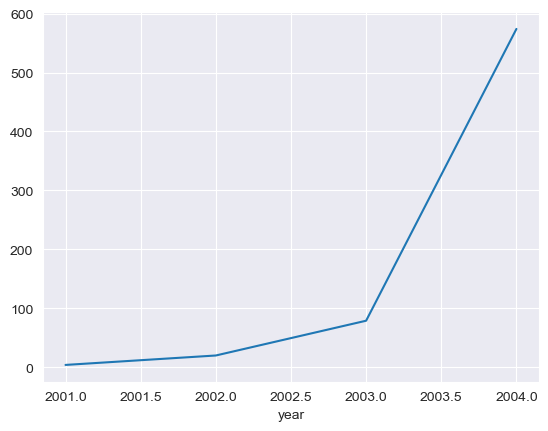

In [27]:
byYearNonEn["Lang"].plot()

<h2> how many people in each topic?

<Axes: xlabel='count', ylabel='topic'>

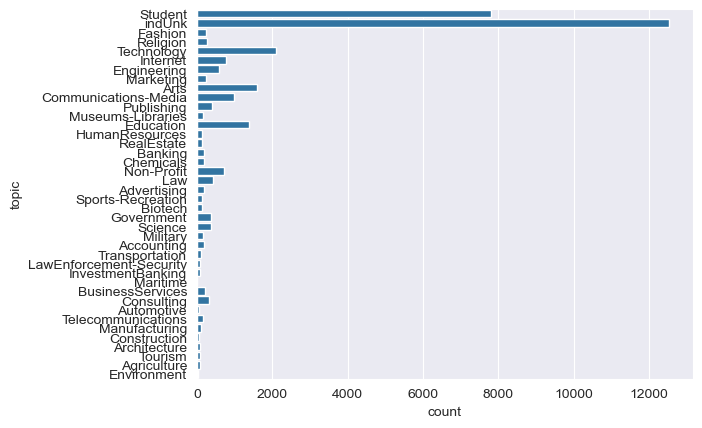

In [28]:
sns.countplot(ndf["topic"])

<h2> what age group is most common?

<Axes: xlabel='age group', ylabel='count'>

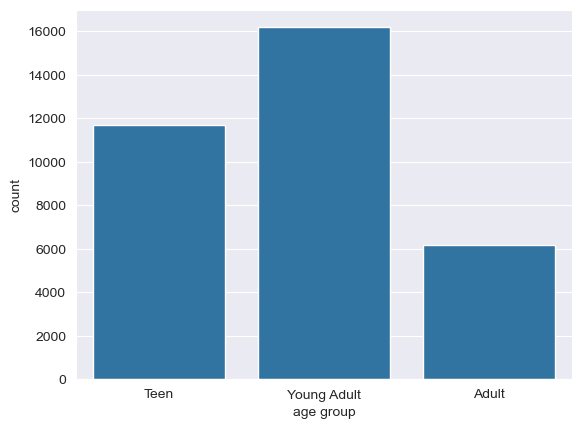

In [29]:
sns.countplot(x= ndf["age group"])

<h2>Topic by age group

<Axes: xlabel='count', ylabel='topic'>

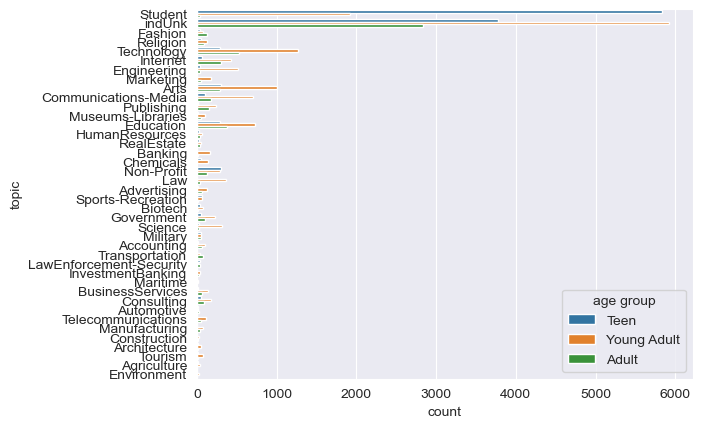

In [64]:
sns.countplot(data=ndf, y= "topic",hue="age group")

<h2> who is more active on the site gender-wise

<Axes: xlabel='gender', ylabel='count'>

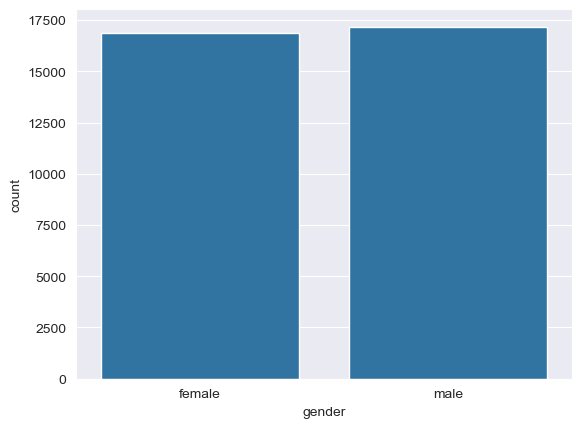

In [31]:
sns.countplot(x= ndf["gender"])

<h2> Topic by Gender

<Axes: xlabel='count', ylabel='topic'>

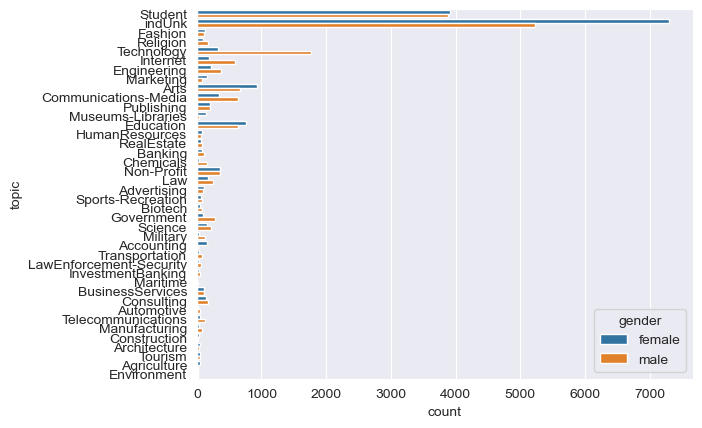

In [63]:
sns.countplot(data=ndf, y= "topic",hue="gender")